# 🦕 JURASSIC PARK: Entrenamiento de Velocirráptores con Machine Learning
## Un viaje por el Pipeline de ML con temática jurásica

---

> *"La vida... se abre camino."* — Dr. Ian Malcolm

Bienvenido al Departamento de Investigación Conductual de **InGen Corporation**.

Tu misión: construir un modelo de Machine Learning capaz de **predecir si un velociráptor atacará o no** basándose en datos de comportamiento observados.

Seguiremos el **pipeline estándar de ML**, paso a paso:

1. 📦 Importar librerías
2. 🔍 Exploración de datos (EDA)
3. 🧹 Preprocesamiento
4. ✂️ División del dataset
5. 🤖 Entrenamiento del modelo
6. 📊 Evaluación
7. 🎯 Predicción en nuevos datos

---

## 📦 PASO 1: Importar las librerías necesarias

Antes de empezar cualquier proyecto de ML, necesitamos cargar nuestras herramientas.
Es como preparar el equipo antes de entrar al recinto de los raptores.

- **pandas**: para manejar datos en tablas
- **numpy**: para cálculos matemáticos
- **matplotlib / seaborn**: para visualizar datos
- **scikit-learn**: la librería de Machine Learning más popular en Python

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Para reproducibilidad (siempre fijar la semilla aleatoria)
np.random.seed(42)  #Normlmente se suele fijar en 42

print("✅ Librerías cargadas. Bienvenido a Jurassic Park.")
print("🦖 InGen Corporation - Departamento de IA Conductual")

✅ Librerías cargadas. Bienvenido a Jurassic Park.
🦖 InGen Corporation - Departamento de IA Conductual


---
## 🔍 PASO 2: Los Datos — El Dataset de los Velocirráptores

Nuestros científicos creado un dataset sintético gracias a los biosensores. Este dataset consta de **400 observaciones** de comportamiento raptor.
Cada fila representa una situación observada con las siguientes características:

| Variable | Descripción | Tipo |
|---|---|---|
| `hambre` | Nivel de hambre (0-10) | Numérica |
| `distancia_presa` | Distancia a la presa en metros | Numérica |
| `temperatura` | Temperatura ambiental (°C) | Numérica |
| `en_manada` | ¿Está en grupo? (1=Sí, 0=No) | Binaria |
| `vocalizaciones` | Sonidos emitidos (por minuto) | Numérica |
| `ataca` | ⚠️ Variable objetivo: ¿Ataca? (1=Sí, 0=No) | Binaria |

**Variable objetivo (target)**: `ataca` — lo que queremos predecir.
**Variables de entrada (features)**: el resto de columnas.

In [76]:
# Generamos el dataset sintético de observaciones de velocirráptores
np.random.seed(42)
n = 400

hambre          = np.random.randint(1, 11, n)
distancia_presa = np.random.randint(1, 50, n)
temperatura     = np.round(np.random.uniform(20, 40, n), 1)
en_manada       = np.random.randint(0, 2, n)
vocalizaciones  = np.random.randint(0, 20, n)

# Regla realista: ataca si hambre alta Y cerca de presa (con algo de ruido)

prob_ataque = (
    0.4 * (hambre / 10) +
    0.3 * (1 - distancia_presa / 50) +
    0.2 * en_manada +
    0.1 * (vocalizaciones / 20)
)

''' 
Aquí estamos convirtiendo una probabilidad (un número entre 0 y 1) en una decisión de sí (1) o no (0).

np.random.normal añade algo de ruido al modelo, así aprender a generalizar y entender tendencias, no a memorizar reglas 
A este valor (0.45) se le llama umbral (threshold). 

    --- Si la suma es mayor a 0.45, el resultado es True (que al convertirlo a entero con .astype(int) se vuelve 1).

    --- Si es menor, es False (se vuelve 0). 
'''

ataca = (prob_ataque + np.random.normal(0, 0.1, n) > 0.5).astype(int) 

# Se genera un dataframe con las variables definidas previamente

df = pd.DataFrame({
    'hambre':           hambre,
    'distancia_presa':  distancia_presa,
    'temperatura':      temperatura,
    'en_manada':        en_manada,
    'vocalizaciones':   vocalizaciones,
    'ataca':            ataca
})

print(f"🦕 Dataset cargado: {df.shape[0]} observaciones, {df.shape[1]} variables")
df.head(10)

🦕 Dataset cargado: 400 observaciones, 6 variables


,hambre,distancia_presa,temperatura,en_manada,vocalizaciones,ataca
0,7,45,23.0,0,16,0
1,4,1,22.8,1,11,1
2,8,16,32.8,0,16,0
3,5,39,23.6,1,9,0
4,7,5,26.9,1,0,1
5,10,22,37.9,0,17,0
6,3,29,29.5,1,17,1
7,7,3,33.4,1,13,1
8,8,12,23.4,1,14,1
9,5,26,23.8,1,11,1


### 2.1 Exploración básica del dataset

Antes de entrenar cualquier modelo, siempre debemos **conocer bien nuestros datos**.
¡No entres al recinto sin saber lo que hay dentro!

In [77]:
# Información general del dataset
print("📋 INFORMACIÓN GENERAL:")
print(df.info())
print()
print("📊 ESTADÍSTICAS DESCRIPTIVAS:")
df.describe()

📋 INFORMACIÓN GENERAL:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   hambre           400 non-null    int32  
 1   distancia_presa  400 non-null    int32  
 2   temperatura      400 non-null    float64
 3   en_manada        400 non-null    int32  
 4   vocalizaciones   400 non-null    int32  
 5   ataca            400 non-null    int64  
dtypes: float64(1), int32(4), int64(1)
memory usage: 12.6 KB
None

📊 ESTADÍSTICAS DESCRIPTIVAS:


,hambre,distancia_presa,temperatura,en_manada,vocalizaciones,ataca
count,400.000000,400.000000,400.000000,400.000,400.000000,400.000000
mean,5.442500,24.862500,29.309250,0.475,9.582500,0.527500
std,2.920276,13.993324,5.626596,0.500,5.807108,0.499868
min,1.000000,1.000000,20.100000,0.000,0.000000,0.000000
25%,3.000000,13.000000,24.200000,0.000,5.000000,0.000000
50%,5.500000,25.000000,29.000000,0.000,10.000000,1.000000
75%,8.000000,36.000000,33.900000,1.000,14.000000,1.000000
max,10.000000,49.000000,39.900000,1.000,19.000000,1.000000


### ¿Cuántos ataques hay en el dataset?

In [78]:
print("DISTRIBUCIÓN DE ATAQUES:")
print(df['ataca'].value_counts())
print()
print(f"Porcentaje de ataques: {df['ataca'].mean()*100:.1f}%")
print(f"Porcentaje de no ataques: {(1-df['ataca'].mean())*100:.1f}%")



DISTRIBUCIÓN DE ATAQUES:
ataca
1    211
0    189
Name: count, dtype: int64

Porcentaje de ataques: 52.8%
Porcentaje de no ataques: 47.2%


### Visualización

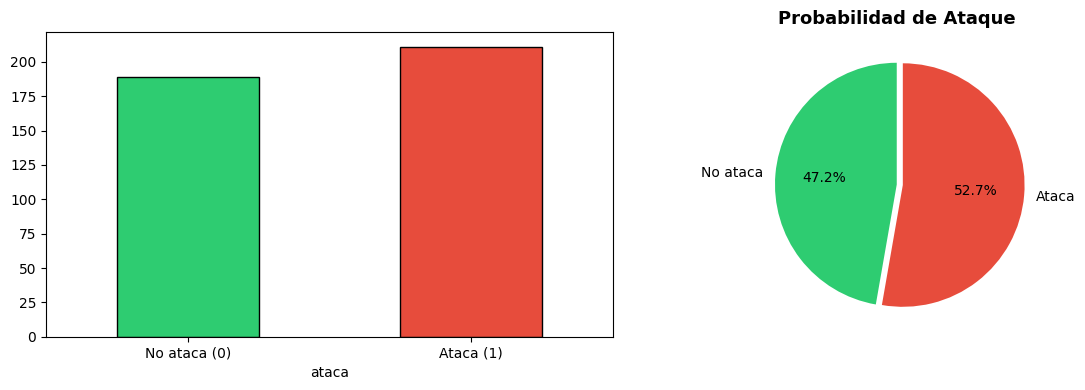

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
conteo = df['ataca'].value_counts().sort_index()  # 0 primero, 1 después
colores = ['#2ecc71', '#e74c3c']  # verde=No ataca, rojo=Ataca

conteo.plot(kind='bar', ax=axes[0], color=colores, edgecolor='black')
axes[0].set_xticklabels(['No ataca (0)', 'Ataca (1)'], rotation=0)

# Gráfico de tipo pie chart
axes[1].pie(
    conteo,
    labels=['No ataca', 'Ataca'],
    colors=colores,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.05)
)

axes[1].set_title('Probabilidad de Ataque', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### ¿Hay valores nulos (datos faltantes)?

In [80]:
print("🔍 VALORES NULOS POR COLUMNA:")
nulos = df.isnull().sum()
print(nulos)
print()
if nulos.sum() == 0:
    print("✅ ¡Ningún valor nulo! Los científicos de InGen hicieron un buen trabajo.")
else:
    print(f"⚠️ Hay {nulos.sum()} valores nulos que deberemos tratar.")

🔍 VALORES NULOS POR COLUMNA:
hambre             0
distancia_presa    0
temperatura        0
en_manada          0
vocalizaciones     0
ataca              0
dtype: int64

✅ ¡Ningún valor nulo! Los científicos de InGen hicieron un buen trabajo.


### Visualizamos la relación entre las variables numéricas y la variable objetivo "Ataque"

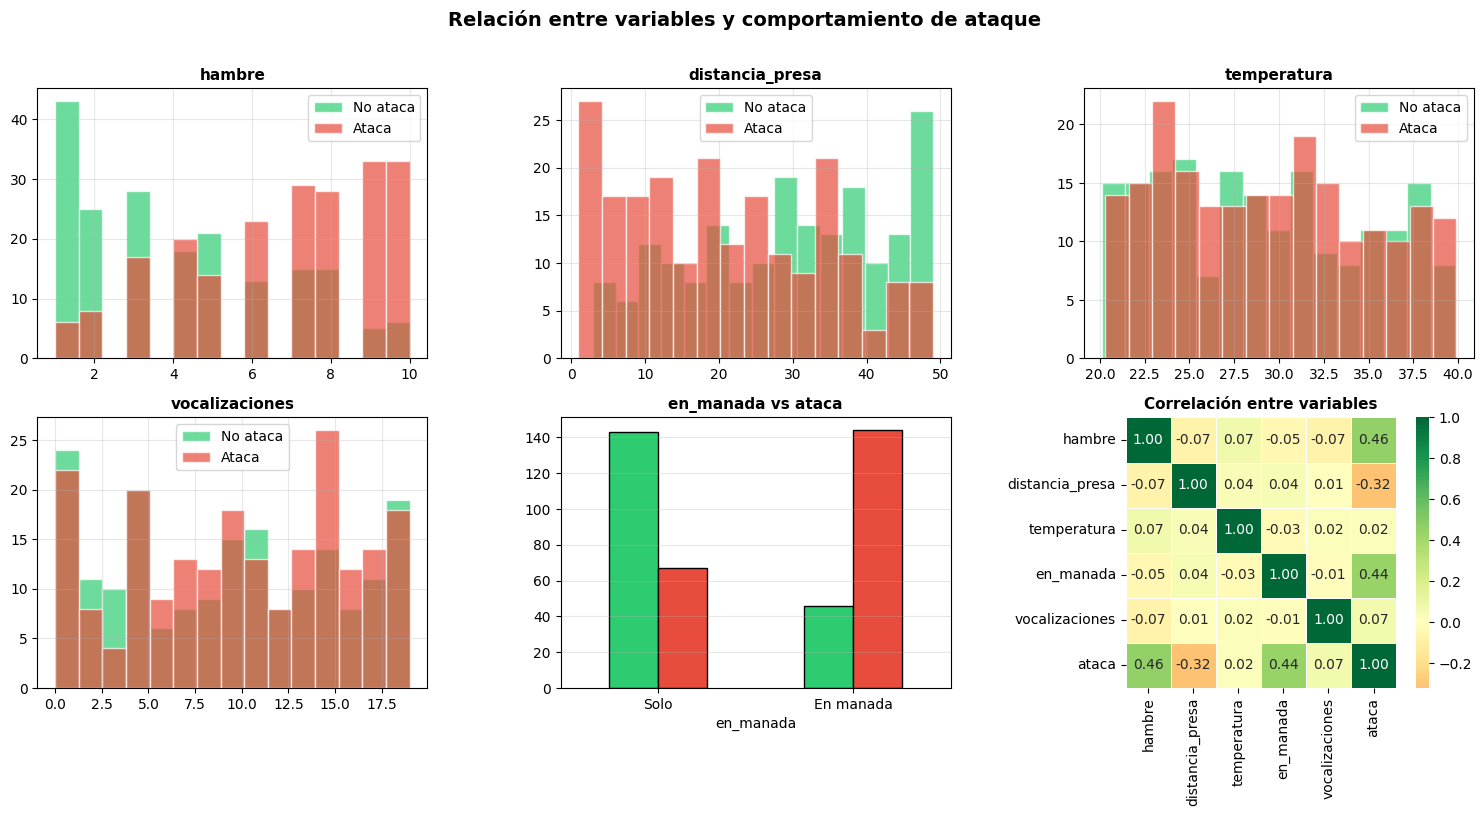

Observa cómo 'hambre' y 'distancia_presa' son las variables más correlacionadas con el ataque.


In [81]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Relación entre variables y comportamiento de ataque', 
             fontsize=14, fontweight='bold', y=1.01)

variables_numericas = ['hambre', 'distancia_presa', 'temperatura', 'vocalizaciones']
colores_raptor = {0: '#2ecc71', 1: '#e74c3c'}

for i, var in enumerate(variables_numericas):
    ax = axes[i // 3][i % 3]
    for clase, color in colores_raptor.items():
        subset = df[df['ataca'] == clase][var]
        ax.hist(subset, alpha=0.7, color=color, 
                label=f"{'Ataca' if clase==1 else 'No ataca'}",
                bins=15, edgecolor='white')
    ax.set_title(f'{var}', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

# En manada - gráfico de barras agrupado
ax = axes[1][1]
manada_ataque = df.groupby(['en_manada', 'ataca']).size().unstack()
manada_ataque.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], 
                   edgecolor='black', legend=False)
ax.set_title('en_manada vs ataca', fontsize=11, fontweight='bold')
ax.set_xticklabels(['Solo', 'En manada'], rotation=0)
ax.grid(axis='y', alpha=0.3)

# Mapa de correlación
ax = axes[1][2]
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, 
            center=0, square=True, linewidths=0.5)
ax.set_title('Correlación entre variables', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Observa cómo 'hambre' y 'distancia_presa' son las variables más correlacionadas con el ataque.")

### Gráfico de dispersión (Scatter Plot) con las variables que más influyen en la probabilidad de ataque

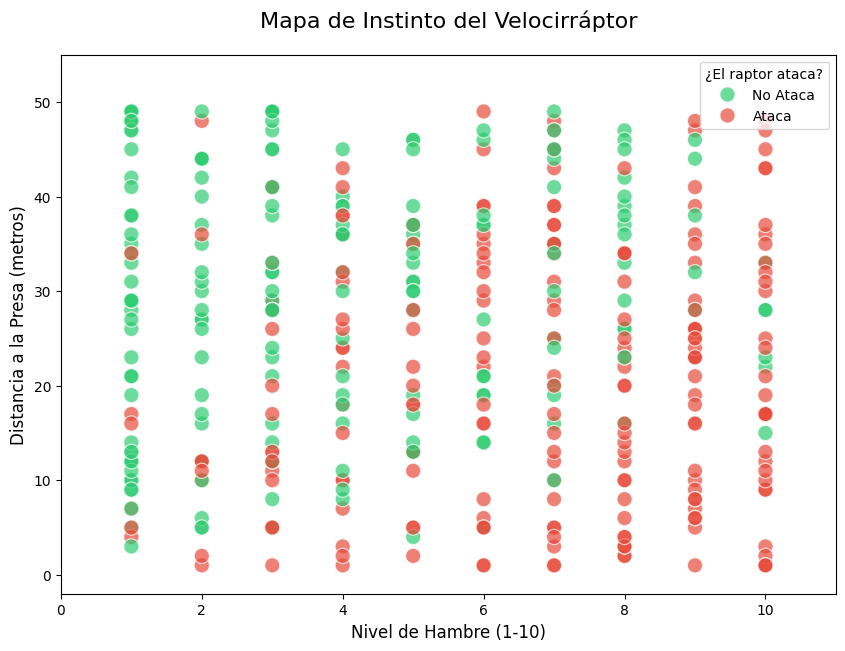

In [82]:
# Definimos tu paleta de colores exacta
colores_raptor = {0: '#2ecc71', 1: '#e74c3c'} # Verde: No ataca, Rojo: Ataca

plt.figure(figsize=(10, 7))

# Creamos el gráfico ajustando los ejes para que no se vea "apretado"
sns.scatterplot(
    data=df, 
    x='hambre', 
    y='distancia_presa', 
    hue='ataca', 
    palette=colores_raptor, 
    s=120,                  # Puntos un poco más grandes
    alpha=0.7,              # Algo de transparencia por si hay puntos uno sobre otro
    edgecolor='w'           # Borde blanco para que resalten más
)

# Ajustamos los límites de los ejes para que el gráfico respire
plt.xlim(0, 11)   # El hambre es de 1 a 10
plt.ylim(-2, 55)  # La distancia es de 1 a 50

# Títulos profesionales
plt.title('Mapa de Instinto del Velocirráptor', fontsize=16, pad=20)
plt.xlabel('Nivel de Hambre (1-10)', fontsize=12)
plt.ylabel('Distancia a la Presa (metros)', fontsize=12)

# Leyenda clara
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['No Ataca', 'Ataca'], title='¿El raptor ataca?')

plt.grid(False)
plt.show()

---
## 🧹 PASO 3: Preprocesamiento de Datos

El preprocesamiento es como limpiar y preparar el recinto antes de la observación.
Necesitamos:

1. **Separar** features (X) del target (y)

In [83]:
# Separamos features (X) y target (y)
X = df.drop('ataca', axis=1)  # Todo menos la variable objetivo
y = df['ataca']                # Solo la variable objetivo

print("Variables de entrada (features):")
print(list(X.columns))
print()
print("Variable objetivo (target): 'ataca'")

Variables de entrada (features):
['hambre', 'distancia_presa', 'temperatura', 'en_manada', 'vocalizaciones']

Variable objetivo (target): 'ataca'


2. **Escalar** las variables numéricas — para que ninguna tenga más "peso" sólo por su escala

> 💡 **¿Por qué escalar?** Un raptor con hambre=9 y otro con distancia_presa=45 tienen valores muy diferentes, pero eso no significa que uno sea más importante. El escalado normaliza todo al mismo rango.

In [84]:
# Escalado de variables numéricas con StandardScaler
# Transforma cada variable para que tenga media=0 y desviación estándar=1

scaler = StandardScaler()

# Solo escalamos las columnas numéricas continuas (no la binaria 'en_manada')
cols_a_escalar = ['hambre', 'distancia_presa', 'temperatura', 'vocalizaciones']

X_scaled = X.copy()
X_scaled[cols_a_escalar] = scaler.fit_transform(X[cols_a_escalar])

print("📊 Datos ANTES del escalado:")
print(X[cols_a_escalar].describe().round(2))
print()
print("📊 Datos DESPUÉS del escalado:")
print(X_scaled[cols_a_escalar].describe().round(2))
print()
print("✅ ¡Perfecto! Ahora todas las variables tienen media≈0 y std≈1")

📊 Datos ANTES del escalado:
       hambre  distancia_presa  temperatura  vocalizaciones
count  400.00           400.00       400.00          400.00
mean     5.44            24.86        29.31            9.58
std      2.92            13.99         5.63            5.81
min      1.00             1.00        20.10            0.00
25%      3.00            13.00        24.20            5.00
50%      5.50            25.00        29.00           10.00
75%      8.00            36.00        33.90           14.00
max     10.00            49.00        39.90           19.00

📊 Datos DESPUÉS del escalado:
       hambre  distancia_presa  temperatura  vocalizaciones
count  400.00           400.00       400.00          400.00
mean     0.00            -0.00         0.00            0.00
std      1.00             1.00         1.00            1.00
min     -1.52            -1.71        -1.64           -1.65
25%     -0.84            -0.85        -0.91           -0.79
50%      0.02             0.01        -0.

---
## ✂️ PASO 4: División del Dataset — Entrenamiento vs. Prueba

Dividimos los datos en dos grupos:
- **Train (entrenamiento)**: el raptor aprende con estos datos — 80%
- **Test (prueba)**: evaluamos el modelo con datos que NUNCA ha visto — 20%

> 💡 Es como entrenar al raptor en el recinto A y luego probarlo en el recinto B. Si sólo lo probamos donde entrenó, no sabremos si realmente aprendió o sólo memorizó.

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,      # 20% para prueba
    random_state=65,    # Reproducibilidad
    stratify=y          # Mantener la proporción de clases
)

print("✂️ DIVISIÓN DEL DATASET:")
print(f"  🏋️ Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  🧪 Prueba:        {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.0f}%)")
print()
print("📊 Distribución en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("📊 Distribución en prueba:")
print(y_test.value_counts(normalize=True).round(3))
print()
print("✅ Las proporciones son similares gracias a 'stratify=y'")

✂️ DIVISIÓN DEL DATASET:
  🏋️ Entrenamiento: 320 muestras (80%)
  🧪 Prueba:        80 muestras (20%)

📊 Distribución en entrenamiento:
ataca
1    0.528
0    0.472
Name: proportion, dtype: float64

📊 Distribución en prueba:
ataca
1    0.525
0    0.475
Name: proportion, dtype: float64

✅ Las proporciones son similares gracias a 'stratify=y'


---
## 🤖 PASO 5: Entrenamiento del Modelo — Árbol de Decisión

Usaremos un **Árbol de Decisión** — un modelo que toma decisiones encadenadas como ramas de un árbol.

Es el modelo perfecto para empezar porque:
- Es **interpretable**: podemos ver exactamente qué reglas aprendió
- Funciona bien para **clasificación binaria** (ataca / no ataca)
- No requiere escalado (aunque lo aplicamos igualmente como buena práctica)

> 🦖 Metáfora: El árbol aprende reglas como *"Si hambre > 7 Y distancia < 10m → ATACA"*

In [86]:
# Creamos y entrenamos el modelo
modelo = DecisionTreeClassifier(
    max_depth=4,       # Limitamos la profundidad para evitar sobreajuste
    random_state=65
)

# ¡El entrenamiento! El modelo aprende de los datos de entrenamiento
modelo.fit(X_train, y_train)

print("🦖 MODELO ENTRENADO:")
print(f"  Tipo: {type(modelo).__name__}")
print(f"  Profundidad máxima permitida: {modelo.max_depth}")
print(f"  Profundidad real aprendida: {modelo.get_depth()}")
print(f"  Número de hojas (decisiones finales): {modelo.get_n_leaves()}")
print()
print("✅ ¡El modelo ha aprendido las reglas de comportamiento del velociráptor!")

🦖 MODELO ENTRENADO:
  Tipo: DecisionTreeClassifier
  Profundidad máxima permitida: 4
  Profundidad real aprendida: 4
  Número de hojas (decisiones finales): 16

✅ ¡El modelo ha aprendido las reglas de comportamiento del velociráptor!


d:\BOOTCAMP_DATA_ANALYST\PIPELINE_ML\.venv\Lib\site-packages\sklearn\tree\_export.py:683: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
d:\BOOTCAMP_DATA_ANALYST\PIPELINE_ML\.venv\Lib\site-packages\sklearn\tree\_export.py:683: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
d:\BOOTCAMP_DATA_ANALYST\PIPELINE_ML\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\BOOTCAMP_DATA_ANALYST\PIPELINE_ML\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


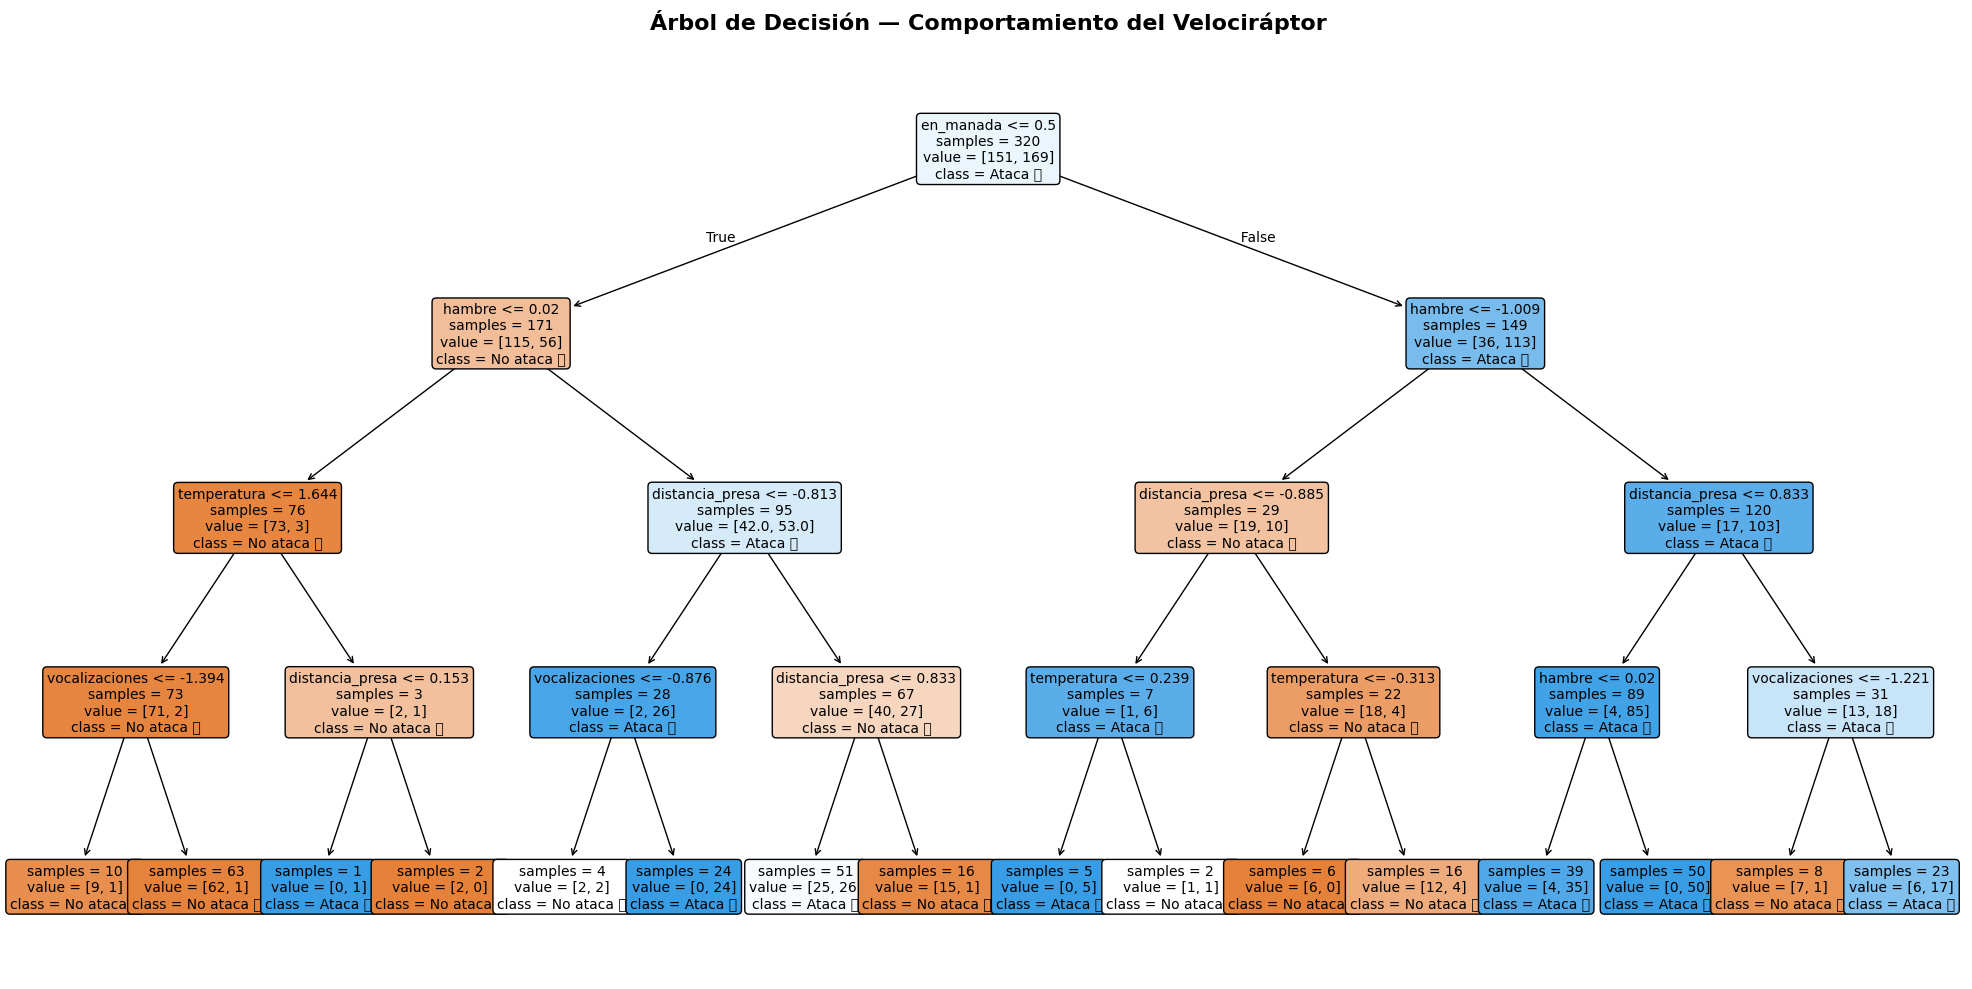

💡 Cada nodo muestra: la pregunta, cuántas muestras llegan ahí, y la clase mayoritaria.
   Azul = tendencia a NO atacar | Naranja = tendencia a ATACAR


In [87]:
# Visualizamos el árbol de decisión
fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(
    modelo,
    feature_names=list(X.columns),
    class_names=['No ataca 🟢', 'Ataca 🔴'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
    impurity=False
)

ax.set_title('Árbol de Decisión — Comportamiento del Velociráptor', 
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("💡 Cada nodo muestra: la pregunta, cuántas muestras llegan ahí, y la clase mayoritaria.")
print("   Azul = tendencia a NO atacar | Naranja = tendencia a ATACAR")

---
## 📊 PASO 6: Evaluación del Modelo

¿Cómo de bien predice nuestro modelo? Usamos varias métricas:

| Métrica | Pregunta que responde |
|---|---|
| **Accuracy** | ¿Qué % de predicciones son correctas? |
| **Precision** | De los que predijo como "ataca", ¿cuántos realmente atacaron? |
| **Recall** | De los que realmente atacaron, ¿cuántos detectó? |
| **F1-Score** | Media harmónica entre precision y recall |

> ⚠️ **Importante**: En este caso, el Recall es crítico. ¡Más vale falsa alarma que no detectar un ataque de velociráptor!

In [88]:
# Predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Métricas principales
acc = accuracy_score(y_test, y_pred)

print("📊 MÉTRICAS DE EVALUACIÓN")
print("=" * 45)
print(f"  🎯 Accuracy (exactitud):  {acc*100:.1f}%")
print()
print("📋 Reporte completo:")
print(classification_report(y_test, y_pred, 
                             target_names=['No ataca', 'Ataca']))

📊 MÉTRICAS DE EVALUACIÓN
  🎯 Accuracy (exactitud):  77.5%

📋 Reporte completo:
              precision    recall  f1-score   support

    No ataca       0.76      0.76      0.76        38
       Ataca       0.79      0.79      0.79        42

    accuracy                           0.78        80
   macro avg       0.77      0.77      0.77        80
weighted avg       0.78      0.78      0.78        80



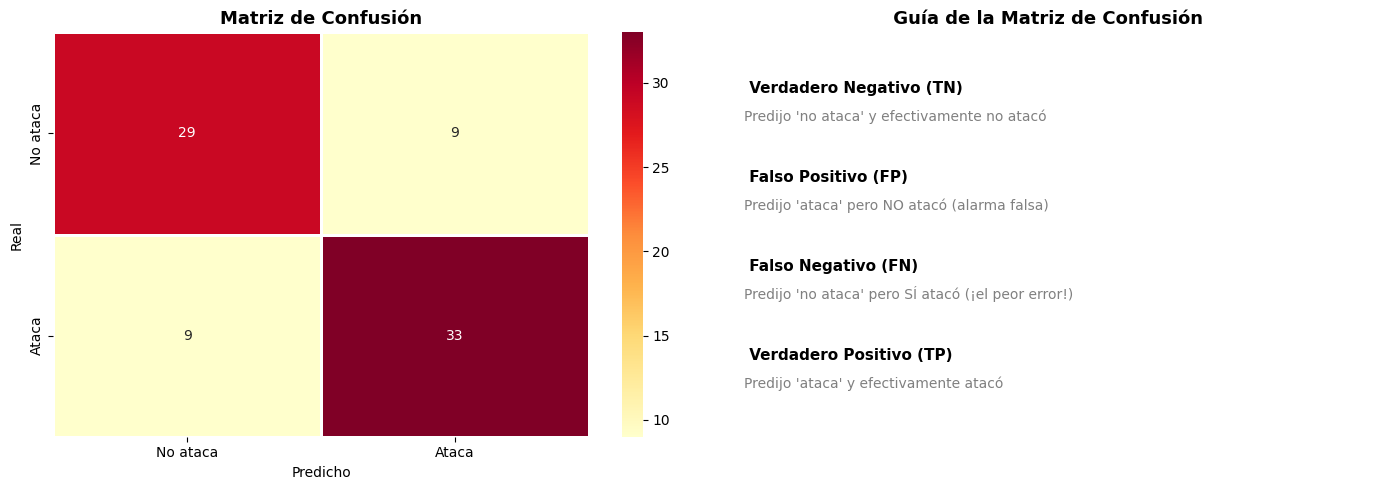

In [89]:
# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['No ataca', 'Ataca'],
            yticklabels=['No ataca', 'Ataca'],
            ax=axes[0], linewidths=1)
axes[0].set_title('Matriz de Confusión', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Anotaciones explicativas
labels = [
    ['Verdadero\nNegativo\n(TN)', 'Falso\nPositivo\n(FP)'],
    ['Falso\nNegativo\n(FN) ', 'Verdadero\nPositivo\n(TP)']
]
ax2 = axes[1]
ax2.axis('off')
ax2.set_title(' Guía de la Matriz de Confusión', fontsize=13, fontweight='bold')

explicaciones = [
    (" Verdadero Negativo (TN)", "Predijo 'no ataca' y efectivamente no atacó"),
    (" Falso Positivo (FP)", "Predijo 'ataca' pero NO atacó (alarma falsa)"),
    (" Falso Negativo (FN)", "Predijo 'no ataca' pero SÍ atacó (¡el peor error!)"),
    (" Verdadero Positivo (TP)", "Predijo 'ataca' y efectivamente atacó"),
]
y_pos = 0.85
for titulo, desc in explicaciones:
    ax2.text(0.05, y_pos, titulo, fontsize=11, fontweight='bold', transform=ax2.transAxes)
    ax2.text(0.05, y_pos - 0.07, desc, fontsize=10, color='gray', transform=ax2.transAxes)
    y_pos -= 0.22

plt.tight_layout()
plt.show()

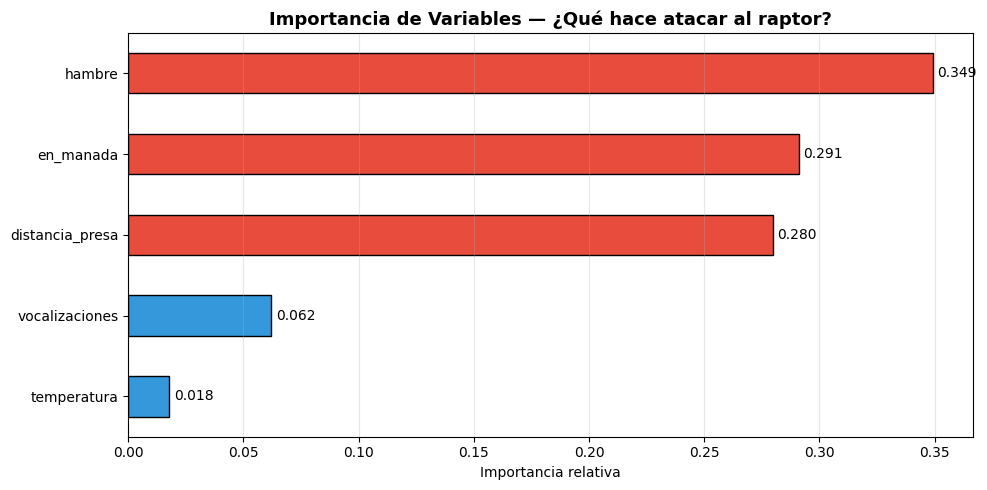

La variable más importante para predecir un ataque es: hambre


In [90]:
# Importancia de cada variable para el modelo
importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

colores_barra = ['#e74c3c' if imp > 0.15 else '#3498db' for imp in importancias]
bars = importancias.plot(kind='barh', ax=ax, color=colores_barra, edgecolor='black')

ax.set_title('Importancia de Variables — ¿Qué hace atacar al raptor?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.grid(axis='x', alpha=0.3)

# Etiquetas de valor
for i, (val, nombre) in enumerate(zip(importancias, importancias.index)):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("La variable más importante para predecir un ataque es:", importancias.idxmax())

---
## 🎯 PASO 7: Predicción en Nuevos Casos

¡El modelo está listo! Ahora podemos usarlo para predecir situaciones reales (o inventadas 🦕).
Veamos qué pasa con algunos escenarios del parque.

In [91]:
# Escenarios para predecir
nuevos_casos = pd.DataFrame({
    'hambre':          [9,  2,  5,  8,  1],
    'distancia_presa': [3,  40, 20, 5,  50],
    'temperatura':     [35, 22, 28, 33, 20],
    'en_manada':       [1,  0,  0,  1,  0],
    'vocalizaciones':  [15, 2,  8,  18, 1],
})

escenarios = [
    "🔴 Raptor muy hambriento, cerca, en manada, calor",
    "🟢 Raptor saciado, lejos, solo, fresco",
    "🟡 Raptor con hambre media, distancia media",
    "🔴 Raptor hambriento, muy cerca, en manada",
    "🟢 Raptor sin hambre, muy lejos, solo",
]

# Escalamos igual que los datos de entrenamiento
nuevos_scaled = nuevos_casos.copy()
nuevos_scaled[cols_a_escalar] = scaler.transform(nuevos_casos[cols_a_escalar])

# Predicciones
predicciones = modelo.predict(nuevos_scaled)
probabilidades = modelo.predict_proba(nuevos_scaled)

print("🦖 PREDICCIONES DEL SISTEMA InGen ML")
print("=" * 60)
for i, (esc, pred, prob) in enumerate(zip(escenarios, predicciones, probabilidades)):
    resultado = "🚨 ATACA" if pred == 1 else "✅ No ataca"
    confianza = max(prob) * 100
    print(f"\nCaso {i+1}: {esc}")
    print(f"  → Predicción: {resultado} (confianza: {confianza:.1f}%)")

print("\n" + "=" * 60)
print("💡 La confianza indica qué tan seguro está el modelo de su predicción")

🦖 PREDICCIONES DEL SISTEMA InGen ML

Caso 1: 🔴 Raptor muy hambriento, cerca, en manada, calor
  → Predicción: 🚨 ATACA (confianza: 100.0%)

Caso 2: 🟢 Raptor saciado, lejos, solo, fresco
  → Predicción: ✅ No ataca (confianza: 98.4%)

Caso 3: 🟡 Raptor con hambre media, distancia media
  → Predicción: ✅ No ataca (confianza: 98.4%)

Caso 4: 🔴 Raptor hambriento, muy cerca, en manada
  → Predicción: 🚨 ATACA (confianza: 100.0%)

Caso 5: 🟢 Raptor sin hambre, muy lejos, solo
  → Predicción: ✅ No ataca (confianza: 90.0%)

💡 La confianza indica qué tan seguro está el modelo de su predicción


---
## 🎉 ¡Enhorabuena! Has completado el Pipeline de Machine Learning

### Resumen de lo que hemos aprendido:

| Paso | ¿Qué hicimos? | Herramienta |
|---|---|---|
| 1. Importar | Cargamos las librerías necesarias | pandas, numpy, sklearn |
| 2. EDA | Exploración y visualización de datos | matplotlib, seaborn |
| 3. Preprocesamiento | Limpieza y escalado | StandardScaler |
| 4. División | Train/Test split | train_test_split |
| 5. Entrenamiento | Ajuste del modelo | DecisionTreeClassifier |
| 6. Evaluación | Medición del rendimiento | classification_report |
| 7. Predicción | Uso del modelo en nuevos datos | modelo.predict() |

### 🦖 Próximos pasos para ir más allá:

- Prueba con otros modelos: **Random Forest**, **Logistic Regression**, **SVM**
- Aprende sobre **validación cruzada** (cross-validation)
- Explora el **ajuste de hiperparámetros** (GridSearchCV)
- Investiga cómo manejar **datasets desbalanceados**

> *"Sus científicos estaban tan preocupados por si podían hacerlo o no, que no se detuvieron a pensar si debían hacerlo."* — Dr. Ian Malcolm
>
> En ML también: siempre reflexiona sobre el **impacto ético** de tus modelos. 🌿